# Logic Study

In [237]:
from pathlib import Path
import pickle
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Configuration

### AIT-LDS V2

In [238]:
# phase_map = {
#     "benign": 0,
#     "phase1": 1,
#     "phase2": 2,
#     "phase3": 3,
#     "phase4": 4,
# }

# plot_labels = [
#     "Benign",
#     "Data Exfiltration",
#     "Scanning",
#     "Exploitation",
#     "Password Cracking",
# ]

In [239]:
# dataset = "aitv2"
# scenario = "santos"
# test_scenario = "santos"

# sim_start = pd.Timestamp("2022-01-14 18:00")
# attack_start = pd.Timestamp("2022-01-17 11:00")
# attack_end   = pd.Timestamp("2022-01-17 12:00")

In [240]:
# Cross-scenario config
# scenario = "santos_fox"
# test_scenario = "fox"

# attack_start = pd.Timestamp("2022-01-18 11:59")
# attack_end   = pd.Timestamp("2022-01-18 13:15")

### DARPA 2000

In [241]:
phase_map = {
    "benign": 0,
    "phase1": 1,
    "phase2": 2,
    "phase3": 3,
    "phase4": 4,
    "phase5": 5,
}

plot_labels = [
    "Benign",
    "Scanning",
    "Probing",
    "Exploitation",
    "Installation",
    "Launching DDoS",
]

In [242]:
dataset = "darpa2000"
scenario = "s1_inside"
test_scenario = "s1_inside"

## Metrics

In [243]:
experiment = "logic_study"
experiment_dir = Path(f"../../experiments/{dataset}/{scenario}/{experiment}")
reports_dir = Path(f"../../reports/{dataset}/{scenario}/{experiment}")
reports_dir.mkdir(parents=True, exist_ok=True)

### Compute attack phase boundaries

In [244]:
df = pd.read_csv(
    f"../../data/interim/{dataset}/{test_scenario}/flows_labeled/all_flows_behavioral.csv"
)

df = df.sort_values("start_time").reset_index(drop=True)

In [245]:
if dataset == "darpa2000":
    df["start_time"] = pd.to_datetime(df["start_time"], unit="s", origin=sim_start)
    # Convert start_time and end_time from seconds to datetime
    df["start_time_dt"] = pd.to_datetime(df["start_time"], unit="s")
    df["end_time_dt"] = pd.to_datetime(df["end_time"], unit="s")

    print(f"Full dataset time range: {df['start_time_dt'].min()} to {df['end_time_dt'].max()}")
    print("Total flows in combined dataset:", len(df))

Full dataset time range: 2052-03-21 08:21:36.476837158 to 2000-03-07 17:35:48.477562785
Total flows in combined dataset: 125825


In [246]:
df["start_time_dt"] = pd.to_datetime(df["start_time_dt"], errors="coerce")

phase_bounds = (
    df[df["phase"] != "benign"]
    .groupby('phase')['start_time_dt']
    .agg(['min', 'max'])
)

phase_starts = phase_bounds['min'].to_dict()

In [247]:
phase_bounds

,min,max
phase,,
0,2052-03-21 08:21:36.476837158,2052-03-21 11:35:46.233426094
1,2052-03-21 08:51:36.142271996,2052-03-21 08:52:00.817878723
2,2052-03-21 09:08:07.354091167,2052-03-21 09:17:10.450980186
3,2052-03-21 09:33:10.611611843,2052-03-21 09:34:59.314250946
4,2052-03-21 09:50:01.749300957,2052-03-21 09:50:53.921429157
5,2052-03-21 10:26:15.437497139,2052-03-21 10:41:19.731715202


### Compute temporal metrics

In [248]:
def is_causal_violation(row, phase_starts):
    pred_phase = row['y_pred']
    t = row['start_time_dt']

    if pred_phase == 0 or pred_phase == 1:
        return False
    
    prev_phase = pred_phase - 1
    
    if prev_phase in phase_starts:
        if t < phase_starts[prev_phase]:
            return True

    return False


def is_regression_violation(row, phase_starts):
    pred_phase = row['y_pred']
    t = row['start_time_dt']

    if pred_phase == 0:
        return False

    next_phase = pred_phase + 1

    if next_phase in phase_starts:
        if t >= phase_starts[next_phase]:
            return True

    return False


def temp_metrics(exp_df, f1, phase_starts):
    df = exp_df.copy()

    df["start_time_dt"] = pd.to_datetime(df["start_time_dt"], errors="coerce")
    df["end_time_dt"] = pd.to_datetime(df["end_time_dt"], errors="coerce")

    df['causal_violation'] = df.apply(
        is_causal_violation,
        axis=1,
        phase_starts=phase_starts
    )

    df['regression_violation'] = df.apply(
        is_regression_violation,
        axis=1,
        phase_starts=phase_starts
    )
    
    correct_df = df[df['phase'] == df['y_pred']]
    wrong_df = df[df['phase'] != df['y_pred']]
    causal_df = wrong_df[wrong_df['causal_violation']]
    regression_df = wrong_df[(~wrong_df['causal_violation']) & (wrong_df['regression_violation'])]

    num_samples = len(df)
    num_wrong = len(wrong_df)
    num_causal = len(causal_df)
    num_regression = len(regression_df)

    error_rate = num_wrong / num_samples if num_samples > 0 else 0  
    causal_rate = num_causal / num_wrong if num_wrong > 0 else 0
    regression_rate = num_regression / num_wrong if num_wrong > 0 else 0

    temp_score = f1 - 0.5 * causal_rate - 0.2 * regression_rate

    dataframes = {
        "correct": correct_df,
        "causal": causal_df,
        "regression": regression_df,
    }

    temp_metrics_dict = {
        "num_wrong": num_wrong,
        "num_causal": num_causal,
        "num_regression": num_regression,
        "error_rate": error_rate,
        "causal_rate": causal_rate,
        "regression_rate": regression_rate,
        "temp_score": temp_score
    }
    
    return dataframes, temp_metrics_dict


In [249]:
results = []
metrics_dict = {}
dataframes_dict = {}

### DPL Models

In [250]:
dpl_experiments = {}

In [251]:
# --- Load metrics ---
metrics_dir = Path(f"../../experiments/{dataset}/{scenario}/{experiment}/deepproblog/metrics")
file_paths = list(metrics_dir.iterdir())
    
for file_path in file_paths:
    experiment_name = str(file_path.stem)

    # Metrics
    data = np.load(file_path, allow_pickle=True)
    print(experiment_name)
    dpl_experiments[experiment_name] = {
        "confusion_matrix": data["confusion_matrix"],
        "classes": data["classes"].tolist(),
        "metrics": data["metrics"].item(),
    }

darpa_temp_baseline_endtoend_base_w10_full_0.001lr_20260526_110556
darpa_temp_pretrained_base_w10_full_0.001lr_20260526_064030
darpa_temp_context_endtoend_base_w10_full_0.001lr_20260526_004847
darpa_temp_context_pretrained_base_w10_full_0.001lr_20260526_021025
darpa_temp_endtoend_base_w10_full_0.001lr_20260526_032241
darpa_temp_context_baseline_endtoend_base_w10_full_0.001lr_20260526_101901


In [252]:
errors_dir = Path(f"../../experiments/{dataset}/{scenario}/{experiment}/deepproblog/errors")
file_paths = list(errors_dir.iterdir())
    
for file_path in file_paths:
    experiment_name = str(file_path.stem)

    with open(file_path, "r") as f:
        errors = json.load(f)
        
    print(experiment_name)
    dpl_experiments[experiment_name]["errors"] = errors

darpa_temp_context_baseline_endtoend_base_w10_full_0.001lr_20260526_101901
darpa_temp_context_endtoend_base_w10_full_0.001lr_20260526_004847
darpa_temp_context_pretrained_base_w10_full_0.001lr_20260526_021025
darpa_temp_baseline_endtoend_base_w10_full_0.001lr_20260526_110556
darpa_temp_endtoend_base_w10_full_0.001lr_20260526_032241
darpa_temp_pretrained_base_w10_full_0.001lr_20260526_064030


In [253]:
correct_dir = Path(f"../../experiments/{dataset}/{scenario}/{experiment}/deepproblog/correct")
file_paths = list(correct_dir.iterdir())
    
for file_path in file_paths:
    experiment_name = str(file_path.stem)

    with open(file_path, "r") as f:
        errors = json.load(f)
        
    print(experiment_name)
    dpl_experiments[experiment_name]["correct"] = errors

darpa_temp_context_baseline_endtoend_base_w10_full_0.001lr_20260526_101901
darpa_temp_context_endtoend_base_w10_full_0.001lr_20260526_004847
darpa_temp_context_pretrained_base_w10_full_0.001lr_20260526_021025
darpa_temp_baseline_endtoend_base_w10_full_0.001lr_20260526_110556
darpa_temp_endtoend_base_w10_full_0.001lr_20260526_032241
darpa_temp_pretrained_base_w10_full_0.001lr_20260526_064030


In [254]:
# Load DPL dataset
test_data_dir = Path(f"../../experiments/{dataset}/{scenario}/{experiment}/deepproblog/cache/")
test_data_path = test_data_dir / "test_data.pkl"
test_data = pickle.load(open(test_data_path, "rb"))
test_data_df = pd.DataFrame(test_data)

In [255]:
for exp_name, exp_data in dpl_experiments.items():
    experiment_name_full = exp_name
    experiment_name = experiment_name_full[:-16] # Remove "run_id"
    print(f"Processing {experiment_name}...")
    
    dpl_to_orig = dict(zip(test_data_df['dpl_index'], test_data_df['orig_index']))

    errors = exp_data["errors"]
    correct = exp_data["correct"]

    original_indices = []
    y_preds = []
    y_trues = []

    for err in errors:
        dpl_index = err['index']
        original_indices.append(dpl_to_orig[dpl_index])
        y_pred = err['predicted']
        y_true = err['actual']
        y_preds.append(phase_map[y_pred])
        y_trues.append(phase_map[y_true])

    for corr in correct:
        dpl_index = corr['index']
        original_indices.append(dpl_to_orig[dpl_index])
        y_pred = corr['predicted']
        y_true = corr['actual']
        y_preds.append(phase_map[y_pred])
        y_trues.append(phase_map[y_true])

    exp_df = df.loc[original_indices].copy()
    exp_df['y_pred'] = y_preds
    exp_df['y_true'] = y_trues

    metrics = exp_data["metrics"]
    macro_f1 = metrics["macro_f1"]

    dataframes, temp_metrics_dict = temp_metrics(exp_df, macro_f1, phase_starts)
    
    metrics_dict[experiment_name] = {
        "macro_f1": metrics["macro_f1"],
        "accuracy": metrics["accuracy"],
        "detection_rate": metrics["detection_rate"],
        "false_alarm_rate": metrics["false_alarm_rate"],
        "num_wrong": temp_metrics_dict["num_wrong"],
        "num_causal": temp_metrics_dict["num_causal"],
        "num_regression": temp_metrics_dict["num_regression"],
        "error_rate": temp_metrics_dict["error_rate"],
        "causal_rate": temp_metrics_dict["causal_rate"],
        "regression_rate": temp_metrics_dict["regression_rate"],
        "temp_score": temp_metrics_dict["temp_score"]
    }

    dataframes_dict[experiment_name] = dataframes

Processing darpa_temp_baseline_endtoend_base_w10_full_0.001lr...
Processing darpa_temp_pretrained_base_w10_full_0.001lr...
Processing darpa_temp_context_endtoend_base_w10_full_0.001lr...
Processing darpa_temp_context_pretrained_base_w10_full_0.001lr...
Processing darpa_temp_endtoend_base_w10_full_0.001lr...
Processing darpa_temp_context_baseline_endtoend_base_w10_full_0.001lr...


### Baseline Models

In [256]:
# Load predictions 
pred_dir = experiment_dir / "baselines" / "predictions"
file_paths = list(pred_dir.iterdir())

predictions_dict = {}
for file_path in file_paths:
    experiment_name = file_path.stem
    print(f"Processing {experiment_name}...")

    predictions = np.load(file_path, allow_pickle=True)
    flow_idx = predictions["flow_idx"]
    y_true = predictions["y_true"]
    y_pred = predictions["y_pred"]

    predictions_dict[experiment_name] = {
        "flow_idx": flow_idx,
        "y_true": y_true,
        "y_pred": y_pred,
    }

Processing ensemble_basefeatures_w10_fulldata_0.001lr...
Processing multiclass_basefeatures_w10_fulldata_0.001lr...


In [257]:
# Load metrics and compute temporal consistency metrics
metrics_dir = experiment_dir / "baselines" / "metrics"
file_paths = list(metrics_dir.iterdir())

for file_path in file_paths:
    experiment_name = file_path.stem
    print(f"Processing {experiment_name}...")

    # Predictions
    pred = predictions_dict[experiment_name]
    flow_idx = pred["flow_idx"]
    y_true = pred["y_true"]
    y_pred = pred["y_pred"]

    # Metrics
    with open(file_path) as f:
        metrics = json.load(f)

    # Compute temporal consistency metrics
    exp_df = df.loc[flow_idx].copy()
    exp_df['y_pred'] = y_pred
    exp_df['y_true'] = y_true
    macro_f1 = metrics["macro_f1"]

    dataframes, temp_metrics_dict = temp_metrics(exp_df, macro_f1, phase_starts)
    
    metrics_dict[experiment_name] = {
        "macro_f1": metrics["macro_f1"],
        "accuracy": metrics["accuracy"],
        "detection_rate": metrics["detection_rate"],
        "false_alarm_rate": metrics["false_alarm_rate"],
        "num_wrong": temp_metrics_dict["num_wrong"],
        "num_causal": temp_metrics_dict["num_causal"],
        "num_regression": temp_metrics_dict["num_regression"],
        "error_rate": temp_metrics_dict["error_rate"],
        "causal_rate": temp_metrics_dict["causal_rate"],
        "regression_rate": temp_metrics_dict["regression_rate"],
        "temp_score": temp_metrics_dict["temp_score"]
    }

    dataframes_dict[experiment_name] = dataframes

Processing ensemble_basefeatures_w10_fulldata_0.001lr...
Processing multiclass_basefeatures_w10_fulldata_0.001lr...


### Create metrics table

In [258]:
results_df = pd.DataFrame(metrics_dict).T
results_df

,macro_f1,accuracy,detection_rate,false_alarm_rate,num_wrong,num_causal,num_regression,error_rate,causal_rate,regression_rate,temp_score
darpa_temp_baseline_endtoend_base_w10_full_0.001lr,0.557611,0.585402,1.000000,0.998341,15649.0,0.0,2258.0,0.414598,0.000000,0.144290,0.528753
darpa_temp_pretrained_base_w10_full_0.001lr,0.854540,0.999364,0.999184,0.000383,24.0,0.0,0.0,0.000636,0.000000,0.000000,0.854540
darpa_temp_context_endtoend_base_w10_full_0.001lr,0.923583,0.999497,0.999230,0.000128,19.0,0.0,0.0,0.000503,0.000000,0.000000,0.923583
darpa_temp_context_pretrained_base_w10_full_0.001lr,0.896637,0.999497,0.999184,0.000064,19.0,0.0,0.0,0.000503,0.000000,0.000000,0.896637
darpa_temp_endtoend_base_w10_full_0.001lr,0.817023,0.999364,0.999048,0.000191,24.0,0.0,1.0,0.000636,0.000000,0.041667,0.808690
darpa_temp_context_baseline_endtoend_base_w10_full_0.001lr,0.946342,0.962485,0.999909,0.090207,1416.0,0.0,1.0,0.037515,0.000000,0.000706,0.946201
ensemble_basefeatures_w10_fulldata_0.001lr,0.802008,0.999311,0.999094,0.000255,26.0,1.0,2.0,0.000689,0.038462,0.076923,0.767393
multiclass_basefeatures_w10_fulldata_0.001lr,0.841486,0.999364,0.999230,0.000319,24.0,1.0,2.0,0.000636,0.041667,0.083333,0.803986


In [259]:
results_df_sorted_f1 = results_df.sort_values("macro_f1", ascending=False)
results_df_sorted_f1

,macro_f1,accuracy,detection_rate,false_alarm_rate,num_wrong,num_causal,num_regression,error_rate,causal_rate,regression_rate,temp_score
darpa_temp_context_baseline_endtoend_base_w10_full_0.001lr,0.946342,0.962485,0.999909,0.090207,1416.0,0.0,1.0,0.037515,0.000000,0.000706,0.946201
darpa_temp_context_endtoend_base_w10_full_0.001lr,0.923583,0.999497,0.999230,0.000128,19.0,0.0,0.0,0.000503,0.000000,0.000000,0.923583
darpa_temp_context_pretrained_base_w10_full_0.001lr,0.896637,0.999497,0.999184,0.000064,19.0,0.0,0.0,0.000503,0.000000,0.000000,0.896637
darpa_temp_pretrained_base_w10_full_0.001lr,0.854540,0.999364,0.999184,0.000383,24.0,0.0,0.0,0.000636,0.000000,0.000000,0.854540
multiclass_basefeatures_w10_fulldata_0.001lr,0.841486,0.999364,0.999230,0.000319,24.0,1.0,2.0,0.000636,0.041667,0.083333,0.803986
darpa_temp_endtoend_base_w10_full_0.001lr,0.817023,0.999364,0.999048,0.000191,24.0,0.0,1.0,0.000636,0.000000,0.041667,0.808690
ensemble_basefeatures_w10_fulldata_0.001lr,0.802008,0.999311,0.999094,0.000255,26.0,1.0,2.0,0.000689,0.038462,0.076923,0.767393
darpa_temp_baseline_endtoend_base_w10_full_0.001lr,0.557611,0.585402,1.000000,0.998341,15649.0,0.0,2258.0,0.414598,0.000000,0.144290,0.528753


In [260]:
results_df_sorted_f1.to_csv(
    reports_dir / "metrics.csv",
    index=True,
)

results_df_sorted_temp = results_df.sort_values("temp_score", ascending=False)
results_df_sorted_temp.head(10)

,macro_f1,accuracy,detection_rate,false_alarm_rate,num_wrong,num_causal,num_regression,error_rate,causal_rate,regression_rate,temp_score
darpa_temp_context_baseline_endtoend_base_w10_full_0.001lr,0.946342,0.962485,0.999909,0.090207,1416.0,0.0,1.0,0.037515,0.000000,0.000706,0.946201
darpa_temp_context_endtoend_base_w10_full_0.001lr,0.923583,0.999497,0.999230,0.000128,19.0,0.0,0.0,0.000503,0.000000,0.000000,0.923583
darpa_temp_context_pretrained_base_w10_full_0.001lr,0.896637,0.999497,0.999184,0.000064,19.0,0.0,0.0,0.000503,0.000000,0.000000,0.896637
darpa_temp_pretrained_base_w10_full_0.001lr,0.854540,0.999364,0.999184,0.000383,24.0,0.0,0.0,0.000636,0.000000,0.000000,0.854540
darpa_temp_endtoend_base_w10_full_0.001lr,0.817023,0.999364,0.999048,0.000191,24.0,0.0,1.0,0.000636,0.000000,0.041667,0.808690
multiclass_basefeatures_w10_fulldata_0.001lr,0.841486,0.999364,0.999230,0.000319,24.0,1.0,2.0,0.000636,0.041667,0.083333,0.803986
ensemble_basefeatures_w10_fulldata_0.001lr,0.802008,0.999311,0.999094,0.000255,26.0,1.0,2.0,0.000689,0.038462,0.076923,0.767393
darpa_temp_baseline_endtoend_base_w10_full_0.001lr,0.557611,0.585402,1.000000,0.998341,15649.0,0.0,2258.0,0.414598,0.000000,0.144290,0.528753


## Plotting

In [261]:
plots_dir = reports_dir / "temp_plots"
plots_dir.mkdir(parents=True, exist_ok=True)

In [262]:
def sample_correct_predictions(correct_df, time_window="1T"):
    correct_attack_df = correct_df[correct_df["y_true"] != 0]
    correct_benign_df = correct_df[correct_df["y_true"] == 0]

    correct_attack_df_sampled = (
        correct_attack_df
        .set_index("start_time_dt")
        .resample(time_window)
        .first()
        .dropna()
        .reset_index()
    )
    correct_benign_df_sampled = (
        correct_benign_df
        .set_index("start_time_dt")
        .resample(time_window)
        .first()
        .dropna()
        .reset_index()
    )

    correct_df_sampled = pd.concat([correct_attack_df_sampled, correct_benign_df_sampled]).sort_values("start_time_dt")

    return correct_attack_df_sampled, correct_benign_df_sampled, correct_df_sampled

In [263]:
def plot_temp_consistency(
    df, 
    phase_bounds, 
    correct_df,
    causal_df,
    regression_df,
    metrics_dict,
    plot_name,
    exp_name, 
    labels,
    out_dir,
    attack_start=None, 
    attack_end=None,
    with_metrics_box=False,
    save_plot=True, 
    show_plot=True,
):
    
    df = df.copy()
    correct_df = correct_df.copy()
    causal_df = causal_df.copy()
    regression_df = regression_df.copy()

    # trim to specified attack window, if provided
    if attack_start is not None and attack_end is not None:
        df["start_time_dt"] = pd.to_datetime(df["start_time_dt"], errors="coerce")
        df["end_time_dt"]   = pd.to_datetime(df["end_time_dt"],   errors="coerce")
        df = df[(df["start_time_dt"] >= attack_start) & (df["end_time_dt"] <= attack_end)]
        
        correct_df   = correct_df[(correct_df["start_time_dt"] >= attack_start) & (correct_df["end_time_dt"] <= attack_end)]
        causal_df      = causal_df[(causal_df["start_time_dt"] >= attack_start) & (causal_df["end_time_dt"] <= attack_end)]
        regression_df  = regression_df[(regression_df["start_time_dt"] >= attack_start) & (regression_df["end_time_dt"] <= attack_end)]

    fig, ax = plt.subplots(figsize=(14, 5))

    edges  = phase_bounds["min"].tolist() + [phase_bounds["max"].iloc[-1]]
    values = phase_bounds.index.tolist()

    ax.stairs(
        values=values,
        edges=edges,
        linewidth=2,
        color="black",
        label="True phase"
    )

    values.append(5)
    ax.fill_between(
        edges,                    
        values,              
        [min(values) - 0.5]*len(values),  
        step="post",
        color="gray",
        alpha=0.2
    )

    ax.scatter(correct_df["start_time_dt"], correct_df["y_pred"], s=25, marker="o",
            color="green", alpha=0.5, label="Correct predictions")

    ax.scatter(causal_df["start_time_dt"], causal_df["y_pred"], s=90, marker="X",
               color="red", alpha=0.9, label="Causal violations")

    ax.scatter(regression_df["start_time_dt"], regression_df["y_pred"], s=90, marker="X",
               color="orange", alpha=0.9, label="Regression violations")

    ax.set_ylim(-0.5, max(values) + 2)
    ax.set_xlim(df["start_time_dt"].min(), df["start_time_dt"].max())
    ax.set_xlabel("Time")
    ax.set_ylabel("Phase")
    ax.set_title(plot_name, fontsize=16)
    ytick_positions = [i for i, _ in enumerate(labels)]
    ax.set_yticks(sorted(ytick_positions))
    ax.set_yticklabels(labels)
    ax.grid(alpha=0.2)

    if with_metrics_box:
        textstr = (
            f"# Total violations: {metrics_dict['num_wrong']}\n"
            f"# Causal violations: {metrics_dict['num_causal']}\n"
            f"# Regression violations: {metrics_dict['num_regression']}\n"
        )

        ax.text(
            0.02, 0.95, textstr,
            transform=ax.transAxes,
            fontsize=12,
            verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
        )
    
    ax.legend(
        frameon=True,
        facecolor="white",
        framealpha=0.9,
        loc="upper right",
        prop={"size": 12}
    )

    fig.tight_layout()

    if save_plot:
        out_path = out_dir / f"{exp_name}.png"
        print(f"Saving plot to {out_path}...")
        fig.savefig(out_path, dpi=300, bbox_inches="tight")

    if show_plot:
        plt.show()

### DPL Models

In [264]:
def get_plot_name(experiment_name):
    # DPL Model Names
    if "temp_context" in experiment_name:
        model_name = "Temporal and Attack-Phase Logic"
    elif "temp" in experiment_name:
        model_name = "Temporal Logic"
    elif "context" in experiment_name:
        model_name = "Attack-Phase Logic"

    if "baseline" in experiment_name:
        plot_name = f"Logic Baseline - {model_name}"
    elif "pretrained" in experiment_name:
        plot_name = f"DPL Pretrained - {model_name}"
    elif "endtoend" in experiment_name:
        plot_name = f"DPL End-to-End - {model_name}"

    # Neural Baseline Names
    if "multiclass" in experiment_name:
        plot_name = "Neural Baseline - Multiclass LSTM"
    elif "ensemble" in experiment_name:
        plot_name = "Neural Baseline - LSTM Ensemble"
    
    return plot_name

Processing darpa_temp_baseline_endtoend_base_w10_full_0.001lr...
Saving plot to ../../reports/darpa2000/s1_inside/logic_study/temp_plots/darpa_temp_baseline_endtoend_base_w10_full_0.001lr_full_window.png...


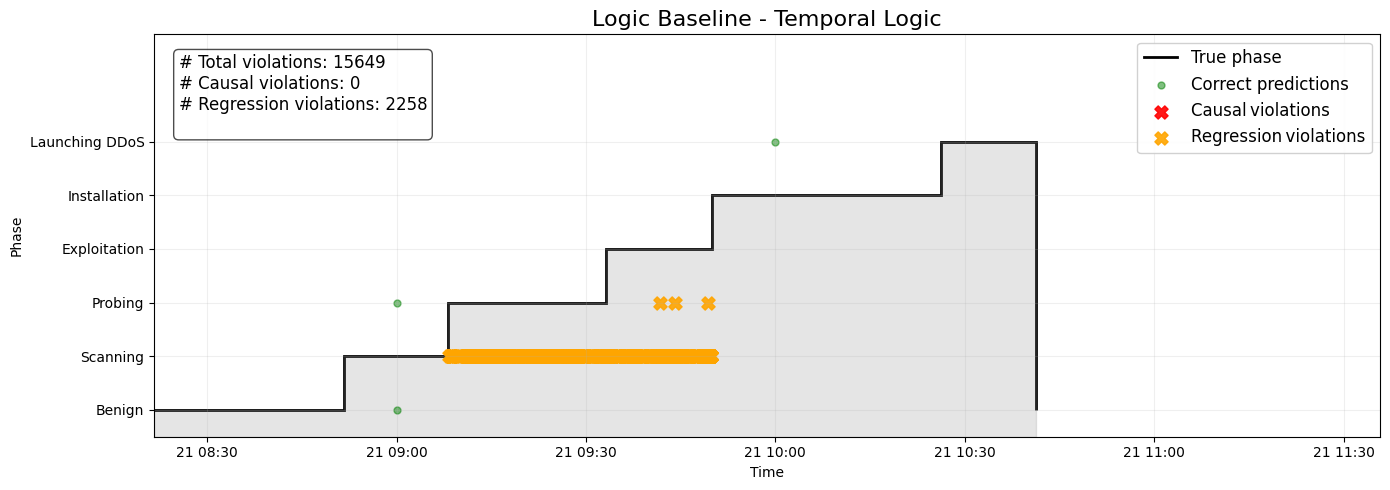

Processing darpa_temp_pretrained_base_w10_full_0.001lr...
Saving plot to ../../reports/darpa2000/s1_inside/logic_study/temp_plots/darpa_temp_pretrained_base_w10_full_0.001lr_full_window.png...


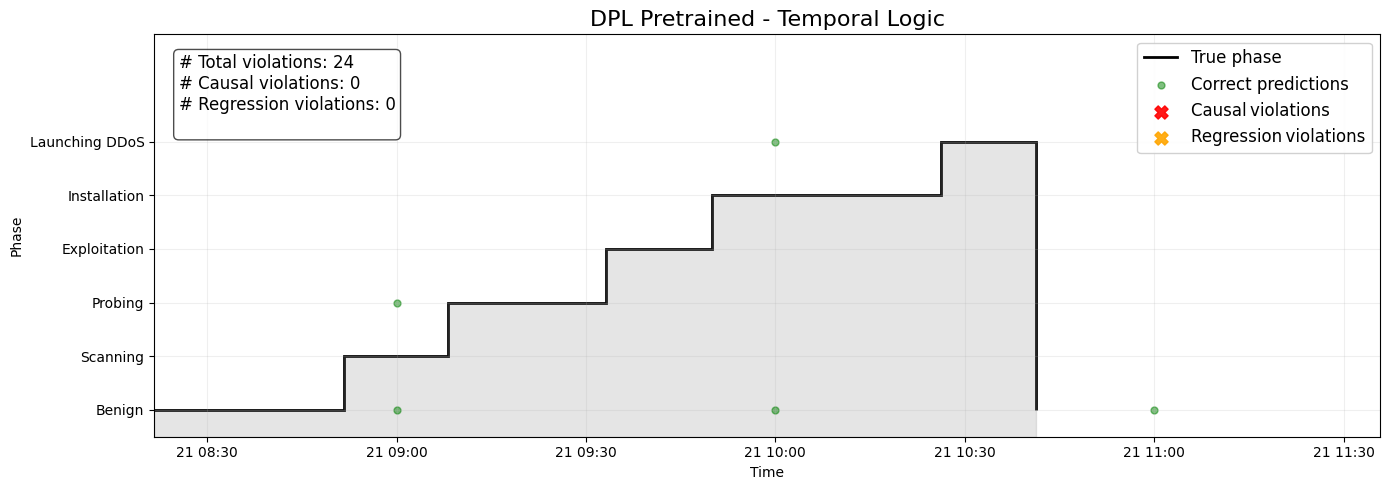

Processing darpa_temp_context_endtoend_base_w10_full_0.001lr...
Saving plot to ../../reports/darpa2000/s1_inside/logic_study/temp_plots/darpa_temp_context_endtoend_base_w10_full_0.001lr_full_window.png...


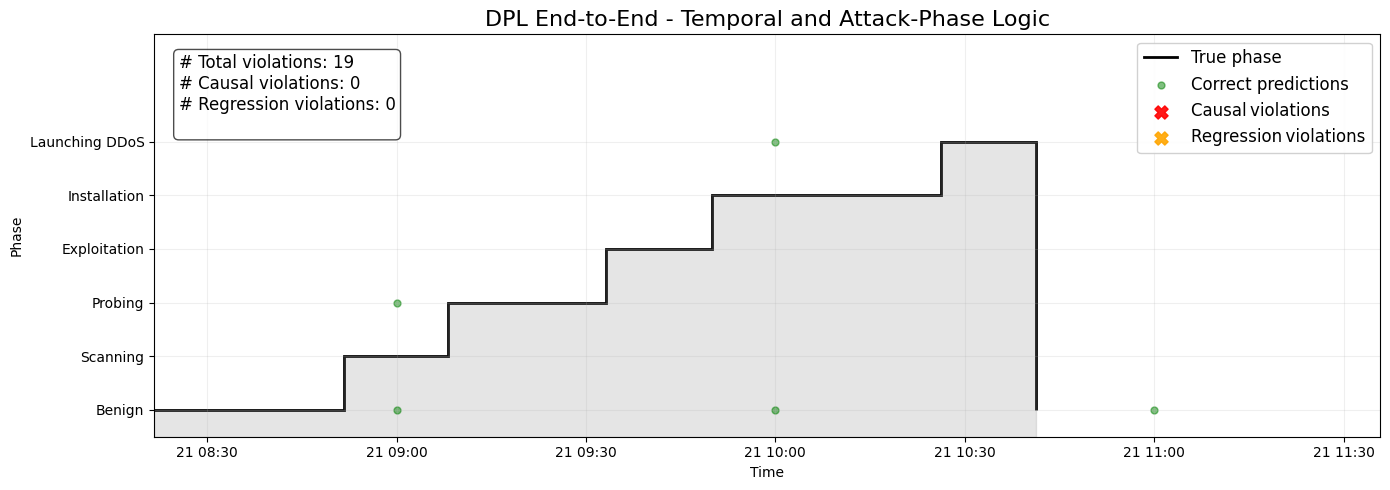

Processing darpa_temp_context_pretrained_base_w10_full_0.001lr...
Saving plot to ../../reports/darpa2000/s1_inside/logic_study/temp_plots/darpa_temp_context_pretrained_base_w10_full_0.001lr_full_window.png...


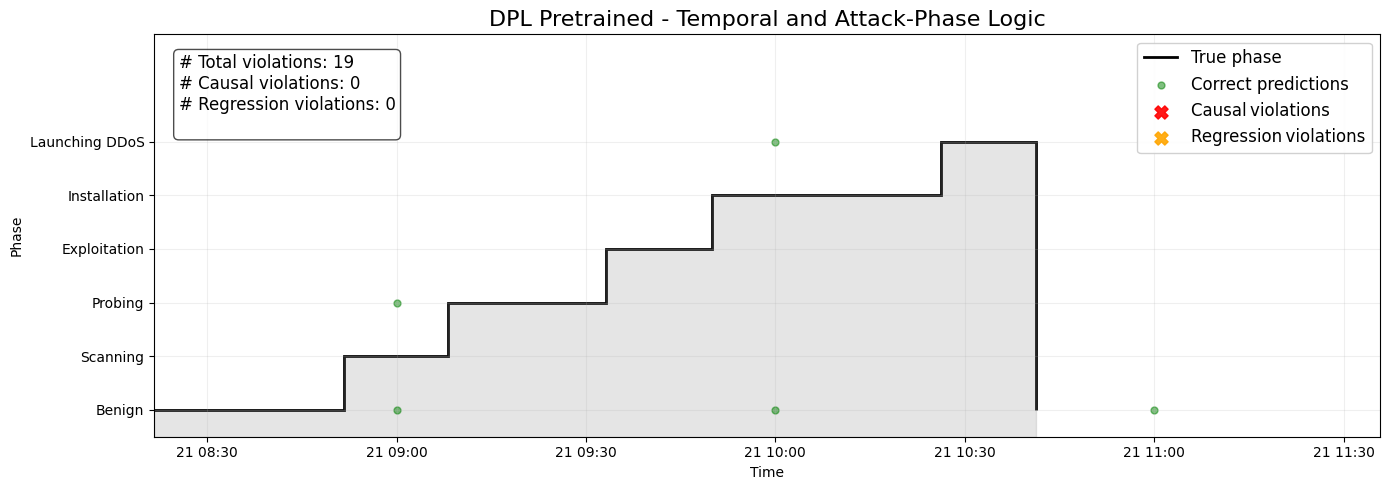

Processing darpa_temp_endtoend_base_w10_full_0.001lr...
Saving plot to ../../reports/darpa2000/s1_inside/logic_study/temp_plots/darpa_temp_endtoend_base_w10_full_0.001lr_full_window.png...


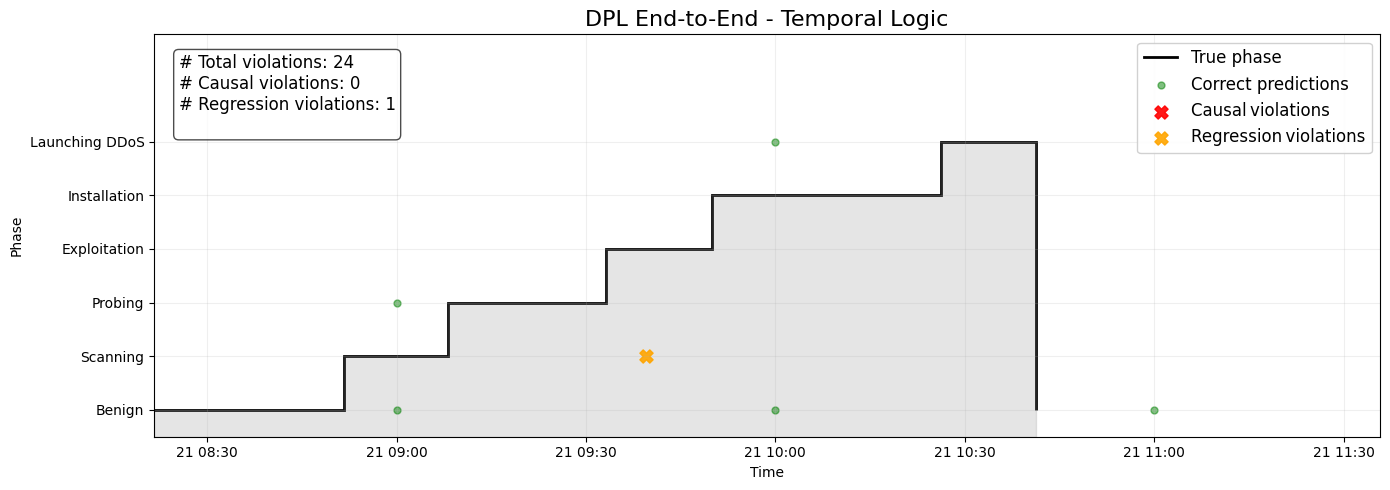

Processing darpa_temp_context_baseline_endtoend_base_w10_full_0.001lr...
Saving plot to ../../reports/darpa2000/s1_inside/logic_study/temp_plots/darpa_temp_context_baseline_endtoend_base_w10_full_0.001lr_full_window.png...


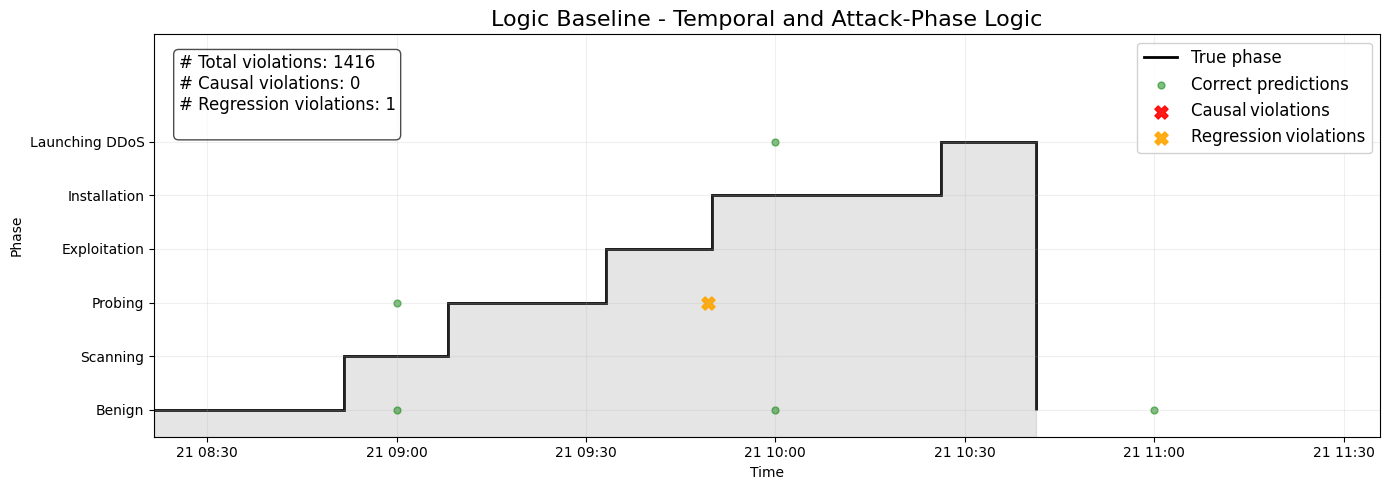

Processing ensemble_basefeatures_w10_fulldata_0.001lr...
Saving plot to ../../reports/darpa2000/s1_inside/logic_study/temp_plots/ensemble_basefeatures_w10_fulldata_0.001lr_full_window.png...


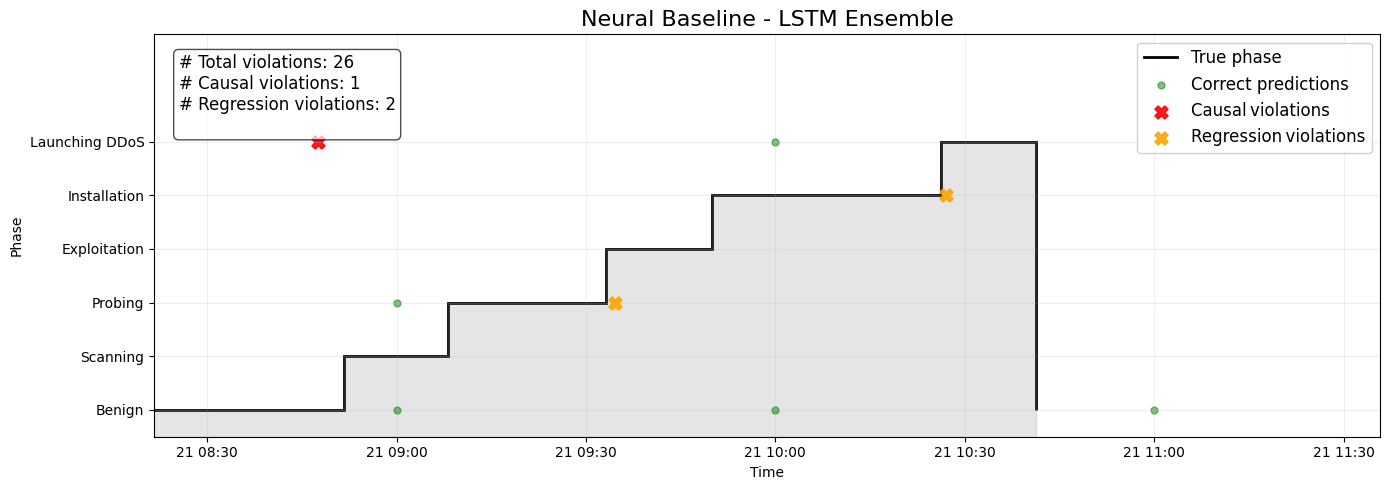

Processing multiclass_basefeatures_w10_fulldata_0.001lr...
Saving plot to ../../reports/darpa2000/s1_inside/logic_study/temp_plots/multiclass_basefeatures_w10_fulldata_0.001lr_full_window.png...


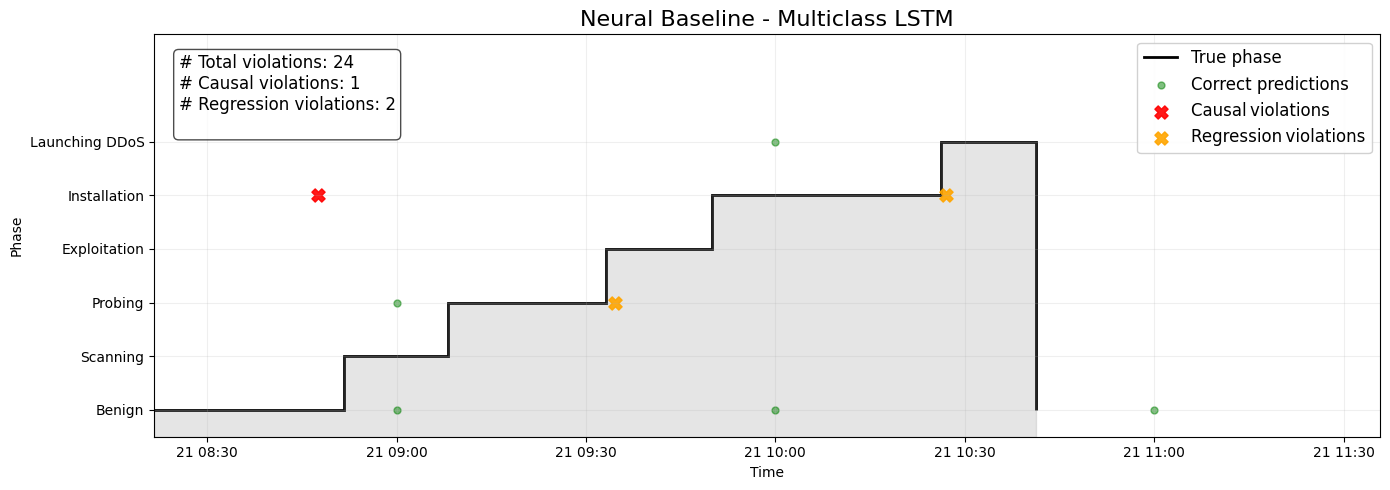

In [265]:
for experiment_name, metrics in metrics_dict.items():
    print(f"Processing {experiment_name}...")
    
    plot_name = get_plot_name(experiment_name)

    dataframes = dataframes_dict[experiment_name]
    correct_df = dataframes["correct"]
    causal_df = dataframes["causal"]
    regression_df = dataframes["regression"]

    # Plot full window
    correct_attack_df_sampled, correct_benign_df_sampled, correct_df_sampled = \
        sample_correct_predictions(correct_df, time_window="1h")
    
    # start = pd.Timestamp("2022-01-14 12:00")
    # end   = pd.Timestamp("2022-01-17 13:30")
    
    plot_temp_consistency(
        df=df,
        phase_bounds=phase_bounds, 
        correct_df=correct_df_sampled,
        causal_df=causal_df,
        regression_df=regression_df,
        metrics_dict=metrics,
        plot_name=plot_name,
        exp_name=f"{experiment_name}_full_window",
        labels=plot_labels,
        out_dir=plots_dir,
        # attack_start=start,
        # attack_end=end,
        with_metrics_box=True,
        save_plot=True,
        show_plot=True
    )

    if dataset == "aitv2":
        # Zoom in on attack window
        correct_attack_df_sampled, correct_benign_df_sampled, correct_df_sampled = \
            sample_correct_predictions(correct_df, time_window="1min")

        # start = attack_start
        # end   = pd.Timestamp("2022-01-17 12:05")
        
        plot_temp_consistency(
            df=df,
            phase_bounds=phase_bounds, 
            correct_df=correct_df_sampled,
            causal_df=causal_df,
            regression_df=regression_df,
            metrics_dict=metrics,
            plot_name=plot_name, 
            exp_name=f"{experiment_name}_zoomed_in",
            labels=plot_labels,
            out_dir=plots_dir,
            # attack_start=start,
            # attack_end=end,
            with_metrics_box=True,
            save_plot=True,
            show_plot=True
        )